<a href="https://colab.research.google.com/github/shayesteh99/DecoDiPhy/blob/main/DecoDiPhy_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#DecoDiPhy: Deconvolving Phylogenetic Distance Mixtures

Decodiphy is a tool that helps you decipher a metagenomic sample by finding an interpretable number of placements on a reference phylogeny.

##Installation

You can install DecoDiPhy directly from github using the command below:

In [ ]:
# Install DecoDiPhy from GitHub
!pip install git+https://github.com/shayesteh99/DecoDiPhy.git

We also need to install a few R packages for drawing purposes of this tutorial. Not required for running DecoDiPhy.

In [ ]:
!R -e "install.packages('jsonlite', repos='https://cloud.r-project.org')"
!R -e "install.packages('stringr', repos='https://cloud.r-project.org')"
!R -e "install.packages('dplyr', repos='https://cloud.r-project.org')"
!R -e "install.packages('tidyverse', repos='https://cloud.r-project.org')"
!R -e "install.packages('viridisLite', repos='https://cloud.r-project.org')"
!R -e "install.packages('ape', repos='https://cloud.r-project.org')"

!R -e "if(!requireNamespace('BiocManager', quietly=TRUE)) install.packages('BiocManager', repos='https://cloud.r-project.org')"
!R -e "BiocManager::install('treeio', ask=FALSE, update=FALSE)"
!R -e "BiocManager::install('ggtree', ask=FALSE, update=FALSE)"

In [12]:
# Download example data
!git clone https://github.com/shayesteh99/DecoDiPhy.git

# Move into repo
%cd DecoDiPhy

Cloning into 'DecoDiPhy'...
remote: Enumerating objects: 198, done.
remote: Counting objects: 100% (198/198), done.
remote: Compressing objects: 100% (140/140), done.
remote: Total 198 (delta 84), reused 141 (delta 47), pack-reused 0 (from 0)
Receiving objects: 100% (198/198), 10.14 MiB | 15.00 MiB/s, done.
Resolving deltas: 100% (84/84), done.
/content/DecoDiPhy/DecoDiPhy


In [3]:
!decodiphy --help

DecoDiPhy 1.5.0
usage: decodiphy [-h] [-t TREE] [-d DISTANCES] [-a ASSIGNMENTS] [-j JPLACE]
                 [-s SEED] [-f FIX_K] [-k K] [-q QUICK] [-r RADIUS]
                 [-m {hill,exhaustive,closest,closest_iterative,reverse_hill}]
                 [-o OUTDIR] [--min_p MIN_P] [--warm_start WARM_START]
                 [--score SCORE] [--optimizer {osqp,cvxpy}]

options:
  -h, --help            show this help message and exit
  -t TREE, --tree TREE  Input tree (default: None)
  -d DISTANCES, --distances DISTANCES
                        Distance file (default: None)
  -a ASSIGNMENTS, --assignments ASSIGNMENTS
                        A placement file with two columns: labels and counts
                        (default: None)
  -j JPLACE, --jplace JPLACE
                        jplace file (default: None)
  -s SEED, --seed SEED  Random Seed (default: 1142)
  -f FIX_K, --fix_k FIX_K
                        Fix k (default: 0)
  -k K, --k K           Number of query taxa if fix_k==1 o

## Example: running DecoDiPhy on the IBD sample

We will follow this tutorial to understand how DecoDiPhy can help with interpretability of metagenomic samples. This sample is taken from the IBD dataset published by [Franzosa et al. 2019](https://doi.org/10.1038/s41564-018-0306-4). We will only look at a particular region of the reference tree (*Oscillospiraceae* family), which is a very well-studied family of bacteria in the context of IBD. The full 16k-taxon reference tree was published in [Balaban et al. 2024](https://doi.org/10.1038/s41587-023-01868-8). For the full analysis of the IBD dataset and more, see [Arasti et al. 2026](https://doi.org/10.64898/2026.01.18.700179).

###krepp results
We use the following R script to show krepp results on this sample. Please note that the original jplace output from krepp has been downsampled 10 times to save disc space.

In [13]:
!Rscript MISC/draw_placements.R Example/krepp_multiplacement.jplace "unweighted" Example/krepp_results.png

ggtree v4.2.0 Learn more at https://yulab-smu.top/contribution-tree-data/

Please cite:

Shuangbin Xu, Lin Li, Xiao Luo, Meijun Chen, Wenli Tang, Li Zhan, Zehan
Dai, Tommy T. Lam, Yi Guan, Guangchuang Yu. Ggtree: A serialized data
object for visualization of a phylogenetic tree and annotation data.
iMeta 2022, 1(4):e56. doi:10.1002/imt2.56

Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.1     ✔ readr     2.2.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ tidyr::expand()  masks ggtree::expand()
✖ dplyr::filter()  masks stats::filter()
✖ purrr::flatten() masks jsonlite::flatten()
✖ dplyr::lag()     masks st

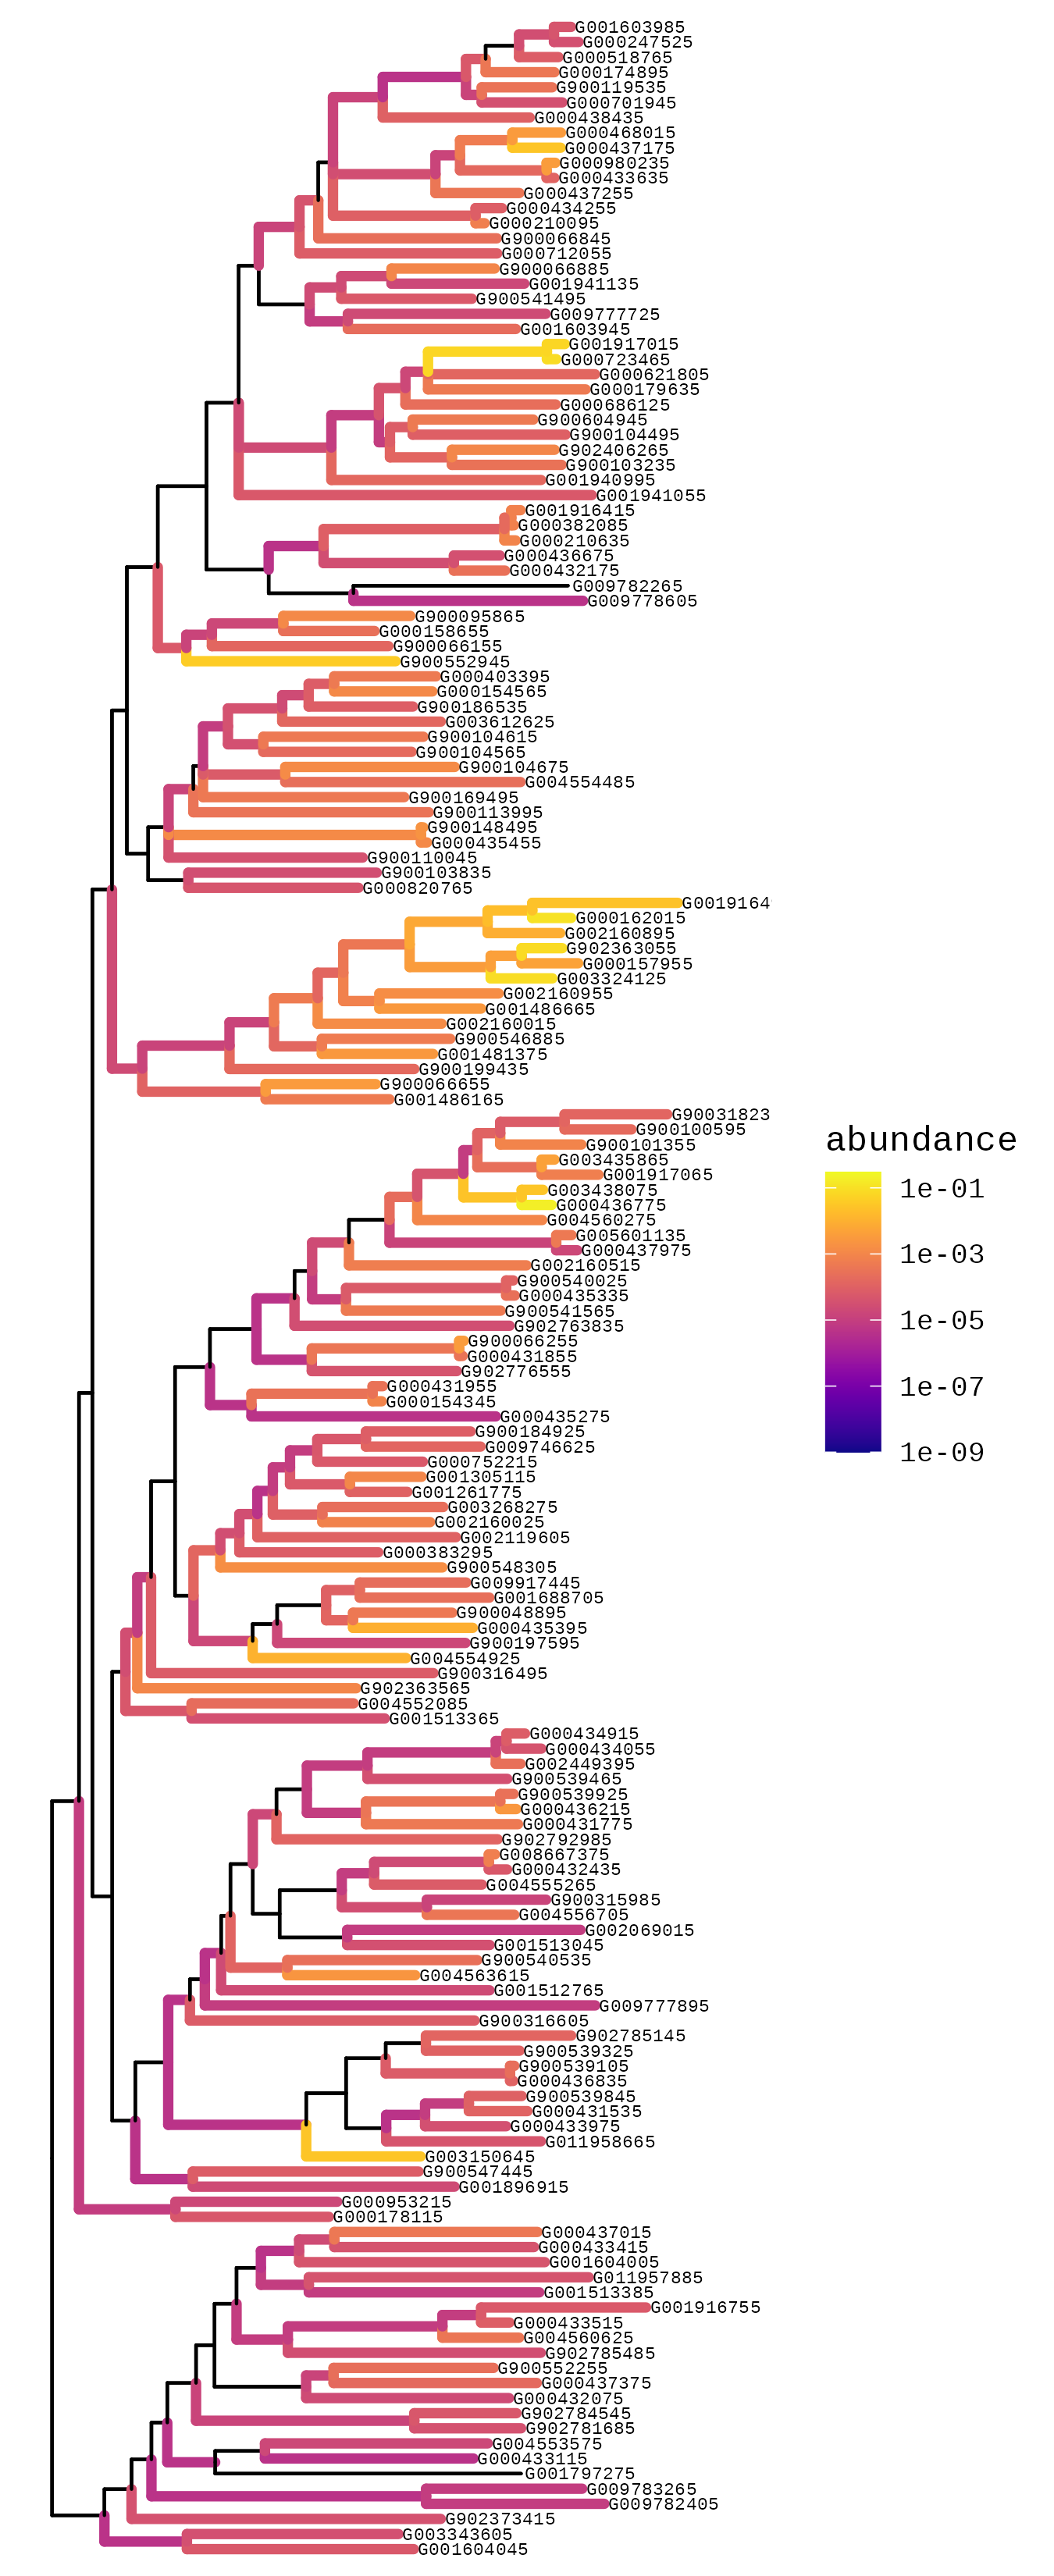

In [14]:
from IPython.display import Image
Image("Example/krepp_results.png", width=400)

##DecoDiPhy Results

To run DecoDiPhy, you can use the jplace output from krepp directly as input to DecoDiPhy. In this case, DecoDiPhy will automatically adjust the number of placements based on the total number of mapped reads in krepp output.

In [16]:
!decodiphy -j Example/krepp_multiplacement.jplace -o Example/output

DecoDiPhy 1.5.0
Total number of reads: 217073.0
Input tree was not labeled! The labeled tree is saved in  Example/output/labeled_tree.trees
Input matrices created!
k =  1
Optimal Placements:  N6823
Loss:  0.3742371347075695
k =  2
Optimal Placements:  N6823 G000436775
Loss:  0.18706515116124864
k =  3
Optimal Placements:  N9296 N11749 N9299
Loss:  0.010488618406128195
k =  4
Optimal Placements:  N9296 N12156 N10791 N7313
Loss:  0.004520466745135359
k =  5
Optimal Placements:  N9296 N12156 N10791 N11752 N6819
Loss:  0.0019069025857579229
k =  6
Optimal Placements:  G000162015 G000436775 N10791 N11286 N6336 N9790
Loss:  0.0007276472574584199
k =  7
Optimal Placements:  G000162015 G000436775 N10791 N10794 N6821 N9295 G003150645
Loss:  0.00047723004952185996
k =  8
Optimal Placements:  G000162015 G000436775 N10791 N11752 N8790 N9790 N7306 G900552945
Loss:  5.866468819894456e-05
k =  9
Optimal Placements:  G000162015 G000436775 N10791 N11752 N8790 N9790 N7306 G900552945 N8307
Loss:  4.18263

In [ ]:
!decodiphy -t Example/pruned_tree.trees -d Example/true_distances.txt -o ./Example

DecoDiPhy 1.3.3
created matrices
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
1
[194]
1
0.0014386326239027795 -2.842050095418309
2
0.0014386326239027795 -2.842050095418309
opt_x:  [0.26430009]
opt_p:  [1.]
opt_y:  0.11609215543527722
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
2
[175  69]
1
0.0008184461206405532 -3.0870099054746287
2
0.0008184461206405532 -3.0870099054746287
opt_x:  [8.29543152e-01 1.01124663e-17]
opt_p:  [0.86929941 0.13070059]
opt_y:  0.10413387800625243
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
3
[175 1